# Goals

### Plot 1. Tune scan
•	D term / B term (Q) (show the best tune for our MD around 24)

•	$\Delta\phi (Q)$

•	$X_{col} (Q)$ (projection of center of the crystal on the collimators, no kick, error bars show projections of the inner and outer parts of the crystal)

•	$\Delta X_{col} (Q) = \sqrt(\beta_{col} \beta_{cry}) sin(\Delta \phi) x’_{cry}  $
 
### Table 1. Q22 optics summary (list of bullet points)
•	Qx =?, Qy=?

•	$\Delta\phi$ TECA->TCSM, $\Delta\phi$ TECA->TPST, $\Delta\phi$ TCSM->TPST

•	D term / B term (at TECA, TCSM and TPST)

•	$\sigma_x$ max,  $\sigma_y$ max
 
### Table 2. Summary for two chosen working points (Just list of bullet points for each of chosen tunes)
•	Qx =?, Qy=? (write down numbers)

•	$\Delta\phi$ TECA->TCSM, \Delta\phi TECA->TPST, \Delta\phi TCSM->TPST

•	D term / B term (at TECA, TCSM and TPST)

•	$\sigma_x$ max, $\sigma_y$ max



In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

# Importing libraries and computing fixed quantities

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import typing as t

import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from shapely.geometry import Polygon

import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc

from cpymad.madx import Madx

# import crystal_extraction.plotters as plotters
# import crystal_extraction.utils as utils
# from crystal_extraction.xsuite_line_creation import create_xsuite_line
# #from crystal_extraction.crystal_extraction import CrystalExtraction
# from crystal_extraction.dummy_crystal import DummyCrystal
# from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

# plotters.my_mpl_style()

from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')
plt.ion()


In [3]:
p = 400.0  # beam momentum (GeV/c)
momentum = p  # beam momentum (GeV/c)
Brho = p * 3.3356  # beam rigidity ???

N_EX = 10e-6
N_EY = 5e-6
BANDWIDTH = 1e-4

proton_mass_GeV = xt.PROTON_MASS_EV * 1e-9
beam_energy_GeV = 400
gamma = beam_energy_GeV / proton_mass_GeV
EX = N_EX / gamma
EY = N_EY / gamma
DPP = 1.5e-3

print(f"Gamma: {gamma}")
print(f"EX: {EX}")
print(f"EY: {EY}")
print(f"deltaP_P: {DPP}")

Gamma: 426.31556991555783
EX: 2.3456802204012262e-08
EY: 1.1728401102006131e-08
deltaP_P: 0.0015


# Uploading the sequence

In [4]:
from elements import install_septa
line = xt.Line.from_json("./lhc_q22.json")


# REFERENCE PARTICLE
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
line.insert_element("tcsm.51932.entry", xt.Marker(), at_s = 5219.6766)
septa_names_with_apertures = install_septa(line, install_zs=True)
line.cycle("TECA.entry", inplace=True)

teca_entry_s = line.get_table()['s', 'TECA.entry']

tw_init = line.twiss(method='4d')
tw0 = tw_init.to_pandas()
tw0.index = tw0.name   


Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


Text(-921.485439159414, -1643.8029640939315, 'TPST')

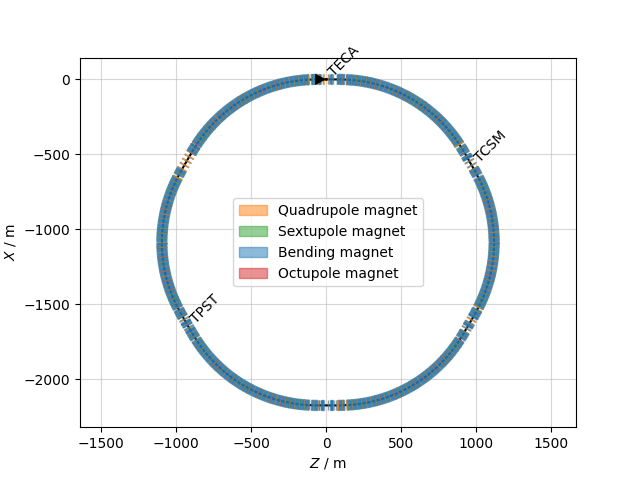

In [5]:
survey = line.survey()
srv = survey.to_pandas()
srv.index = srv.name
fig, ax = plt.subplots()

survey.plot(labels=False, ax=ax)
teca_e = srv.loc['TECA.entry']
tcsm_e = srv.loc['tcsm.51932.entry']
tpst_e = srv.loc['tpst.21760_entry']

ax.text(teca_e.Z, teca_e.X, "TECA", ha='left', va='bottom', rotation=45)
ax.text(tcsm_e.Z, tcsm_e.X, "TCSM", ha='left', va='bottom', rotation=45)
ax.text(tpst_e.Z, tpst_e.X, "TPST", ha='left', va='bottom', rotation=45)


Q22 tune
Qx = 22.13000000004881
Qy = 22.180000000010537


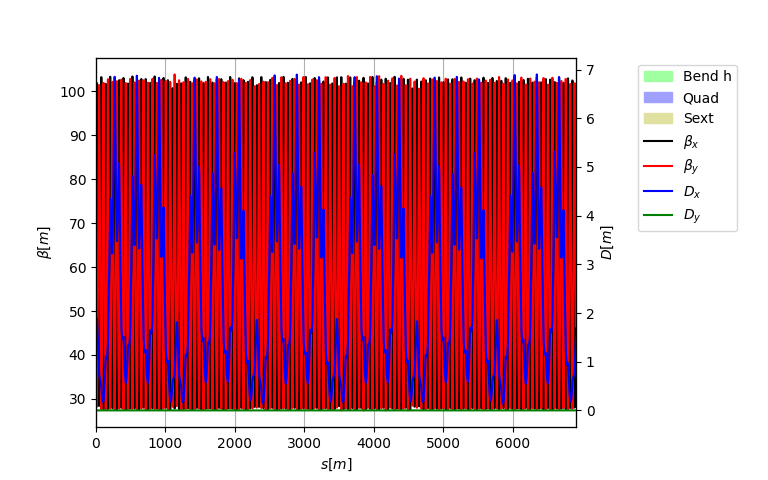

In [6]:
qx0 = tw_init.qx
qy0 = tw_init.qy
print('Q22 tune')
print('Qx =', qx0)
print('Qy =', qy0)
tw_init.plot()

In [7]:
# #COMPUTING THE TWISS PARAMETERS AT THE TECA LOCATION TO COMPARE THE TUNES  
# max_betx = tw0['betx'].max()
# min_betx = tw0['betx'].min()

# # DISPERSION ALONG THE RING
# max_dx = tw0['dx'].max()
# min_dx = tw0['dx'].min()

# DISPERSION AND BETX AT THE TECA LOCATION
betx_teca = tw0.loc['TECA.entry'].betx
dx_teca = tw0.loc['TECA.entry'].dx

# COMPUTING THE BEAM SIZE 
tw0['sx_mm'] = np.sqrt(tw0['betx'] * EX + (tw0['dx'] * DPP)**2) * 1e3
tw0['sy_mm'] = np.sqrt(tw0['bety'] * EY + (tw0['dy'] * DPP)**2) * 1e3
    
B_term0 = betx_teca * EX
D_term0 = (dx_teca * DPP)**2
ratio0 = D_term0 / B_term0

print(f'D term / B term = {ratio0:.2f}')
print(f"sigma_x max = {tw0.sx_mm.max():.2f} mm")
print(f"sigma_y max = {tw0.sy_mm.max():.2f} mm")

D term / B term = 3.31
sigma_x max = 10.47 mm
sigma_y max = 1.10 mm


$\max \sigma(s) = \max \sqrt{(\varepsilon \beta(s) + (D(s) \cdot \delta_p)^2)} \neq \sqrt{(\varepsilon \beta_{max} + (D_{max} \cdot \delta_p)^2)}$

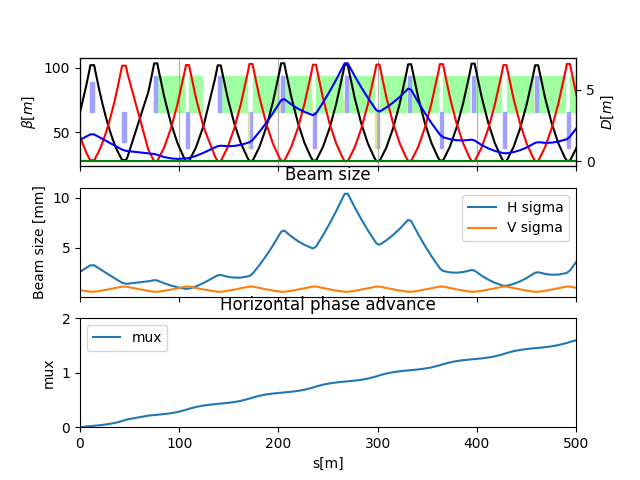

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(3, sharex=True)
tw_init.plot(ax=ax1)
ax1.set_xlim(teca_e.s, teca_e.s+500)
tw0.plot(x='s', y=['sx_mm', 'sy_mm'], label=['H sigma', 'V sigma'], title='Beam size', xlabel='s[m]', ylabel='Beam size [mm]', xlim=(teca_e.s, teca_e.s+500), ax=ax2);
tw0.plot(x='s', y='mux', title='Horizontal phase advance', xlabel='s[m]', ylabel='mux', xlim=(teca_e.s, teca_e.s+500), ylim=(0, 2), ax=ax3);

# Tweaking tunes 15 to 26 for the tunes

In [14]:
tune_range = np.arange(15, 27, 1) + 0.05
tune_range, tune_range.size

(array([15.05, 16.05, 17.05, 18.05, 19.05, 20.05, 21.05, 22.05, 23.05,
        24.05, 25.05, 26.05]),
 12)

In [10]:
def match_tunes(line, qx, qy):
    # Extraction tunes
    opt = line.match(solve=False,
                     method='4d',
        vary=[
            xt.VaryList(['kqf', 'kqd'], step=1e-7),   # Varying quadrupole focal strengths
            xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4),   # Varying phase values
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-5),    # Desired target tunes
        ])
    return opt

In [11]:
from theory import *
from elements import TECA

In [12]:
tw = line.twiss(method='4d')
R_matrix = tw_init.get_R_matrix(start='TECA.entry', end='tpst.21760_entry')
R_matrix.shape #  R matrix is 6x6 x px y py zeta delta

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


(6, 6)

In [25]:
DELTA_Q = 0.05

delta_x = lambda bet0, bet1, dpx, dmu: np.sqrt(bet0 * bet1) * dpx * np.sin(dmu)
# x_col = # TODO: Compute the x at the collimator

x_col = lambda bet0, bet1, alf0, x0, px0, dmu: \
    np.sqrt(bet0 / bet1) * (np.cos(dmu) + alf0 * np.sin(dmu)) * (x0) +\
    np.sqrt(bet0 * bet1) * np.sin(dmu) * px0

results = []

# Loop over the range of tunes
step = 1
tune_range = np.arange(15, 27, step) + DELTA_Q
for i, tune in enumerate(tune_range):
    print(f"Tune matching {i+1}/{len(tune_range)}: Qx = {tune:.2f}")
    
    # Match the tunes
    try:
        opt = match_tunes(line, tune, tune + DELTA_Q)
        opt.solve() 
    except:
        print(f"Failed to match tunes: Qx = {tune:.2f}")
        results.append({})
        continue  

    # Recalculate the Twiss parameters after setting the tunes
    tw_table = line.twiss(method='4d')
    tw = tw_table.to_pandas()
    tw.index = tw.name
    
    # Beam size
    tw['sx_mm'] = np.sqrt(tw['betx'] * EX + (tw['dx'] * DPP)**2) * 1e3
    tw['sy_mm'] = np.sqrt(tw['bety'] * EY + (tw['dy'] * DPP)**2) * 1e3
    sx_max_mm = tw['sx_mm'].max()
    sy_max_mm = tw['sy_mm'].max()
    
    # Ratio
    tw['ratio'] = (tw['dx'] * DPP)**2 / (tw['betx'] * EX)

    # Offset
    #tw['delta_x'] = delta_x(tw.loc['TECA.entry'].betx, tw['betx'], TECA.tilt, tw['mux'] - tw.loc['TECA.entry'].mux)
    tw['r11'] = [tw_table.get_R_matrix(start='TECA.entry', end=elem)[0, 0] for elem in tw.index]
    tw['r12'] = [tw_table.get_R_matrix(start='TECA.entry', end=elem)[0, 1] for elem in tw.index]
    tw['delta_x'] = tw['r12'] * TECA.bending_angle
    tw['xcol'] = tw['r11'] * (TECA.jaw + TECA.width/2) + tw['r12'] * TECA.tilt
    
    teca = tw.loc['TECA.entry']
    tcsm = tw.loc['tcsm.51932.entry']
    tpst = tw.loc['tpst.21760_entry']
    
    # Phase advance
    dmu_teca_tcsm = (tcsm.mux - teca.mux) % 1
    dmu_teca_tpst = (tpst.mux - teca.mux) % 1
    dmu_tcsm_tpst = (tpst.mux - tcsm.mux) % 1

    output = dict(
        tune=tune,
        actual_tune_x=tw_table.qx,
        actual_tune_y=tw_table.qy,
        sx_max_mm=sx_max_mm,
        sy_max_mm=sy_max_mm,
        ratio_teca=tw.loc['TECA.entry'].ratio,
        ratio_tcsm=tw.loc['tcsm.51932.entry'].ratio,
        ratio_tpst=tw.loc['tpst.21760_entry'].ratio,
        dmu_teca_tcsm=dmu_teca_tcsm,
        dmu_teca_tpst=dmu_teca_tpst,
        dmu_tcsm_tpst=dmu_tcsm_tpst,
        delta_x_tscm=tw.loc['tcsm.51932.entry'].delta_x,
        delta_x_tpst=tw.loc['tpst.21760_entry'].delta_x,
        xcol_tscm=tw.loc['tcsm.51932.entry'].xcol,
        xcol_tpst=tw.loc['tpst.21760_entry'].xcol
    )
    results.append(output)

Tune matching 1/12: Qx = 15.05
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elements are replaced by drifts
The line 

/opt/homebrew/lib/python3.11/site-packages/xtrack/linear_normal_form.py:186: RuntimeWarning: invalid value encountered in sqrt
  n2 = 1./np.sqrt(np.matmul(np.matmul(a2, S), b2))


The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.        
In the twiss computation collective elements are replaced by drifts
The line has collective elements.        
In the twiss computation collective elements are replaced by drifts
The line has collective elements.        
In the twiss computation collective elements are replaced by drifts
The line has collective elements.        
In the twiss computation collective elements are replaced by drifts
The line has collective elements.        
In the twiss computation collective elements are replaced by drifts
The line has collective elements.        
In the twiss computation collective elements are replaced by drifts
The line has collective elements.        
In the twiss computation collective elements are replaced by drifts
The line has collective elements.        
In the twiss computation collective elements are replaced by drifts
The line has colle

In [26]:
res = pd.DataFrame(results)
res

,tune,actual_tune_x,actual_tune_y,sx_max_mm,sy_max_mm,ratio_teca,ratio_tcsm,ratio_tpst,dmu_teca_tcsm,dmu_teca_tpst,dmu_tcsm_tpst,delta_x_tscm,delta_x_tpst,xcol_tscm,xcol_tpst
0,15.05,15.049998,15.100000,18.627166,1.190978,8.959263,4.341327,8.971618,0.601592,0.023971,0.422378,-0.007113,0.002130,0.050081,-0.052410
1,16.05,16.050000,16.100000,18.426050,1.158920,25.823856,15.007965,19.237687,0.779205,0.690478,0.911273,-0.010476,-0.012115,0.017688,0.046177
2,17.05,17.050000,17.100000,22.910385,1.146728,73.690428,51.295136,83.356249,0.953422,0.355517,0.402096,-0.002938,0.009803,-0.030337,0.008852
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19.05,19.050010,19.100010,17.840913,1.122324,20.668895,12.926134,23.144110,0.295873,0.688134,0.392261,0.008491,-0.010525,-0.001101,0.032253
5,20.05,20.050001,20.100001,12.269374,1.115620,1.261480,0.668681,1.178822,0.470732,0.353555,0.882823,0.001555,0.008699,0.033530,0.018956
6,21.05,21.050000,21.100001,10.606293,1.117245,0.188286,0.075865,0.186074,0.638711,0.020769,0.382057,-0.006258,0.001391,0.026445,-0.046516
7,22.05,22.050001,22.100001,10.479286,1.105114,3.003943,1.382417,2.465279,0.813013,0.686128,0.873115,-0.006980,-0.009446,-0.010927,0.021310
8,23.05,23.050001,23.100001,12.812816,1.102997,15.854807,7.359658,16.307005,0.988075,0.351623,0.363548,-0.000545,0.007955,-0.033348,0.027111
9,24.05,24.050001,24.100001,117.588531,1.109090,5618.098051,2508.635431,5480.070513,0.157791,0.019346,0.861556,0.005885,0.001176,-0.015715,-0.044521


In [27]:
res.to_pickle('tune_matching.pkl')

## Plotting the results


<Axes: title={'center': 'Offset'}, xlabel='Qx', ylabel='Offset [m]'>

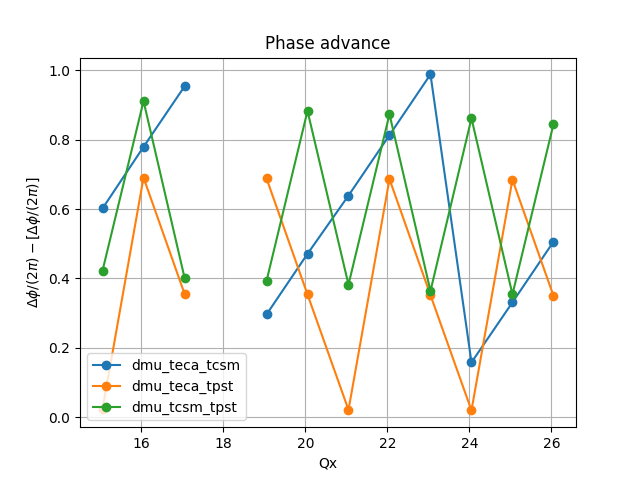

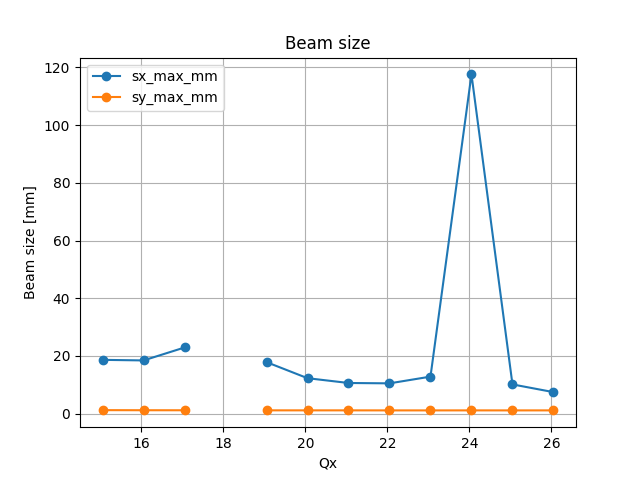

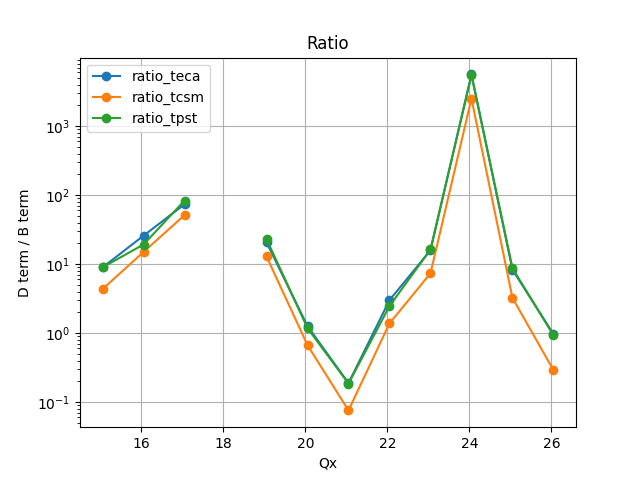

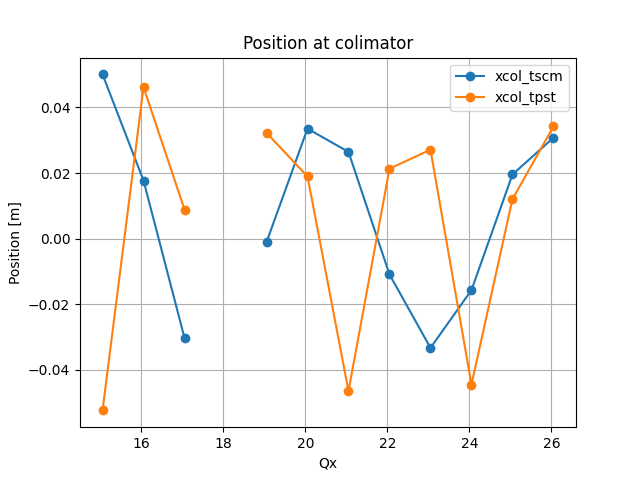

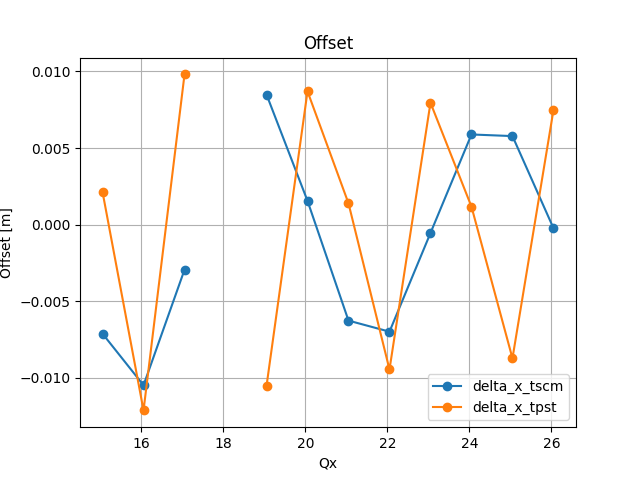

In [36]:
res = pd.read_pickle('tune_matching.pkl')
res.index = res.actual_tune_x

res.plot(kind='line', marker='o', y=['dmu_teca_tcsm', 'dmu_teca_tpst', 'dmu_tcsm_tpst'], title='Phase advance', xlabel='Qx', ylabel='$\Delta \phi / (2\pi) - [\Delta \phi / (2\pi)]$', grid=True)

res.plot(kind='line', marker='o', y=['sx_max_mm', 'sy_max_mm'], title='Beam size', xlabel='Qx', ylabel='Beam size [mm]', grid=True)

res.plot(kind='line', marker='o', y=['ratio_teca', 'ratio_tcsm', 'ratio_tpst'], title='Ratio', xlabel='Qx', ylabel='D term / B term', grid=True, logy=True)

res.plot(kind='line', marker='o', y=['xcol_tscm', 'xcol_tpst'], title='Position at colimator', xlabel='Qx', ylabel='Position [m]', grid=True)

res.plot(kind='line', marker='o', y=['delta_x_tscm', 'delta_x_tpst'], title='Offset', xlabel='Qx', ylabel='Offset [m]', grid=True)